In [22]:
import datetime as dt
from dateutil.relativedelta import relativedelta
import data_provider.DataReader as data_provider
from trading.MACDStrategy import MACD1226
import config as cfg
import yahoo_fin.stock_info as yf
import pandas as pd
import backtrader as bt
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline


In [355]:
end_date = dt.datetime.now()
start_date = end_date - relativedelta(days=20)
data = data_provider.yFinanceReader().historic_price_data("xlm-usd", start_date, end_date)

In [356]:
class MACD1226(bt.Strategy):
    # list of parameters which are configurable for the strategy
    params = (
        # Standard MACD Parameters
        ("macd1", 12),
        ("macd2", 26),
        ("macdsig", 9),
        ("atrperiod", 14),  # ATR Period (standard)
        ("atrdist", 3.0),  # ATR distance for stop price
        ("smaperiod", 30),  # SMA Period (pretty standard)
        ("dirperiod", 10),  # Lookback period to consider SMA trend direction
    )

    def __init__(self):
        self.macd = bt.indicators.MACD(
            self.data,
            period_me1=self.p.macd1,
            period_me2=self.p.macd2,
            period_signal=self.p.macdsig,
        )

        self.macd_epsilon = 0.006

        self.rsi_alert = False
        self.macd_cross_alert = False
        self.sma_cross_alert = False
        self.first_position = True

        self.rsi = bt.indicators.RSI_SMA(self.data.close, period=14)

        # Cross of macd.macd and macd.signal
        self.mcross = bt.indicators.CrossOver(self.macd.macd, self.macd.signal)

        # To set the stop price
        #self.atr = bt.indicators.ATR(self.data, period=self.p.atrperiod)

        self.sma = bt.indicators.SMA(self.data, period=self.p.smaperiod)
        self.smadir = self.sma - self.sma(-self.p.dirperiod)
        self.smacross = bt.indicators.CrossOver(self.data.close, self.sma)
        self.macd_diff = (abs(abs(self.macd.signal) - abs(self.macd.macd)))/(self.data.close)

    def log(self, txt, dt=None):
        ''' Logging function for this strategy'''
        dt = dt or self.datas[0].datetime.date(0)
        print('%s, %s' % (dt.isoformat(), txt))

    def next(self):
        if not self.position:  # not in the market
            if (self.data.close[0] > self.sma) and (self.macd.signal < self.macd.macd):
                if self.first_position:
                    self.log('BUY, %.6f %.6f %.6f' % (self.data.close[0], self.macd.signal[0] - self.macd.macd[0], self.rsi[0]))
                    self.buy()  # enter long position
                    self.first_position = False
                else:
                    if (self.macd_diff > self.macd_epsilon) and self.rsi < 60:
                        self.log('BUY, %.6f %.6f %.6f' % (self.data.close[0], self.macd.signal[0] - self.macd.macd[0], self.rsi[0]))
                        self.buy()  # enter long position
                    

        if self.rsi >80:  # if fast MA crosses above slow MA
            self.log("set rsi slert %.6f %.6f" % (self.rsi[0], self.macd_diff[0]))
            self.rsi_alert = True

        if self.smacross > 0:
            #if not self.sma_cross_alert:
            #    self.log("set sma slert %.6f" % 1)
            self.sma_cross_alert = True
            
        if self.smacross < 0:
            #if self.sma_cross_alert:
            #    self.log("set sma slert %.6f" % 0)
            self.sma_cross_alert = False
            

        if self.mcross < 0:
            #if not self.macd_cross_alert:
            #    self.log("set macd cross %.6f" % 1)
            self.macd_cross_alert = True
            
        if self.mcross > 0:
            #if self.macd_cross_alert:
            #    self.log("set macd cross %.6f" % 0)
            self.macd_cross_alert = False
            
        #if self.rsi_alert and self.sma_cross_alert and self.macd_cross_alert:
        #    self.log("macd diff %.6f" % self.macd_diff[0])

        if self.position:
            if self.rsi_alert and (self.macd_diff > self.macd_epsilon):
                #print(self.macd_diff[0])
                if (self.macd_diff > self.macd_epsilon):
                    self.log('SELL, %.6f %.6f %.6f %.6f' % (self.data.close[0], self.macd_diff[0], self.macd.signal[0], self.macd.macd[0]))
                    self.sell()
                    self.rsi_alert = False
                    self.macd_cross_alert = False
                    self.sma_cross_alert = False
                


Starting Portfolio Value: 100000.00
2023-10-28, BUY, 0.113114 -0.000128 55.219527
2023-10-29, set rsi slert 90.955980 0.001526
2023-11-06, set rsi slert 82.780724 0.003166
2023-11-06, set rsi slert 84.089799 0.003987
2023-11-09, set rsi slert 83.031651 0.002005
2023-11-09, SELL, 0.119972 0.007899 -0.000115 -0.001063
Final Portfolio Value: 100000.01


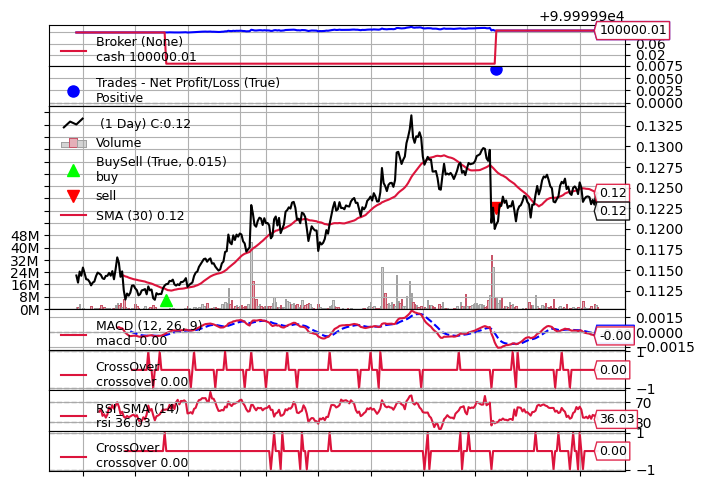

[[<Figure size 640x480 with 8 Axes>]]

In [357]:
cerebro = bt.Cerebro()
cerebro.broker.setcash(100000.0)
cerebro.addstrategy(MACD1226)
cerebro.adddata(bt.feeds.PandasData(dataname=data))
print('Starting Portfolio Value: %.2f' % cerebro.broker.getvalue())
cerebro.run()
print('Final Portfolio Value: %.2f' % cerebro.broker.getvalue())
cerebro.plot(iplot=False)